# Bank Customer Churn - EDA

Just the exploratory part of the project. Dataset is `European_Bank.csv`, 10,000 customers from France/Spain/Germany.

Modeling and SHAP stuff live in `src/train_model.py` and `src/explain.py` instead of here, since I wanted those runnable as standalone scripts for the app rather than tied to a notebook.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

df = pd.read_csv('../data/European_Bank.csv')
df.shape

(10000, 14)

## 1. First look at the data

In [7]:
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [9]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Good - no missing values anywhere, so no imputation needed. Also noticed `Year` is just 2025 for every single row, so that's getting dropped before modeling along with `CustomerId` and `Surname` (neither of which mean anything to a model anyway).

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,10000.0,2.025000e+03,0.000000,2025.00,2025.00,2.025000e+03,2.025000e+03,2025.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


## 2. How imbalanced is the target?

Overall churn rate: 20.37%


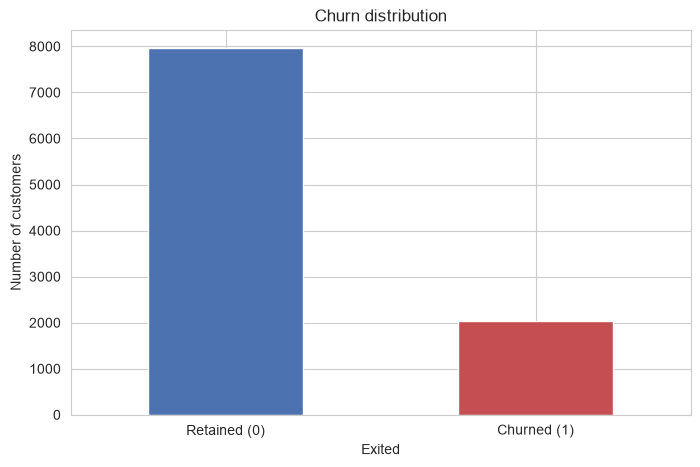

In [11]:
churn_rate = df['Exited'].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

fig, ax = plt.subplots()
df['Exited'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#4C72B0', '#C44E52'])
ax.set_xticklabels(['Retained (0)', 'Churned (1)'], rotation=0)
ax.set_ylabel('Number of customers')
ax.set_title('Churn distribution')
plt.show()

About 1 in 5 churned. Not crazy imbalanced but enough that I used class weighting in training and picked the best model by ROC-AUC instead of accuracy (accuracy alone would be misleading here - a model that just predicts "retained" every time gets ~80% for free).

## 3. Churn by geography and gender

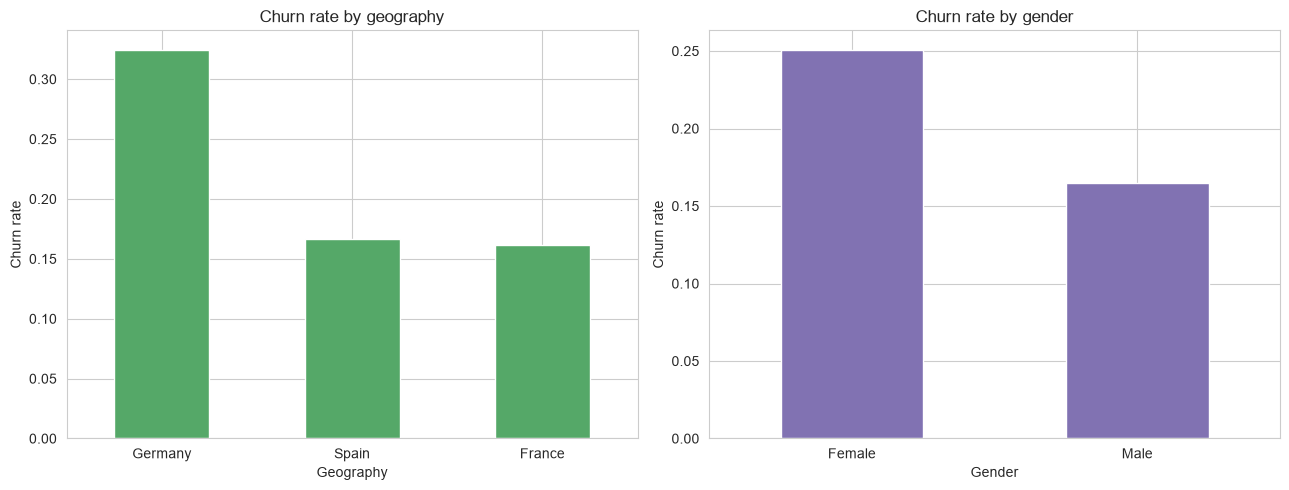

Geography
Germany    0.324432
Spain      0.166734
France     0.161548
Name: Exited, dtype: float64

Gender
Female    0.250715
Male      0.164559
Name: Exited, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

geo_churn = df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
geo_churn.plot(kind='bar', ax=axes[0], color='#55A868')
axes[0].set_ylabel('Churn rate')
axes[0].set_title('Churn rate by geography')
axes[0].tick_params(axis='x', rotation=0)

gender_churn = df.groupby('Gender')['Exited'].mean()
gender_churn.plot(kind='bar', ax=axes[1], color='#8172B2')
axes[1].set_ylabel('Churn rate')
axes[1].set_title('Churn rate by gender')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(geo_churn)
print()
print(gender_churn)

Germany jumps out - churn rate is noticeably higher than France or Spain even though the customer counts are similar. Wasn't expecting that going in. Female customers also churn a bit more than male, though the gap is smaller.

## 4. Age, balance, and product holdings vs churn

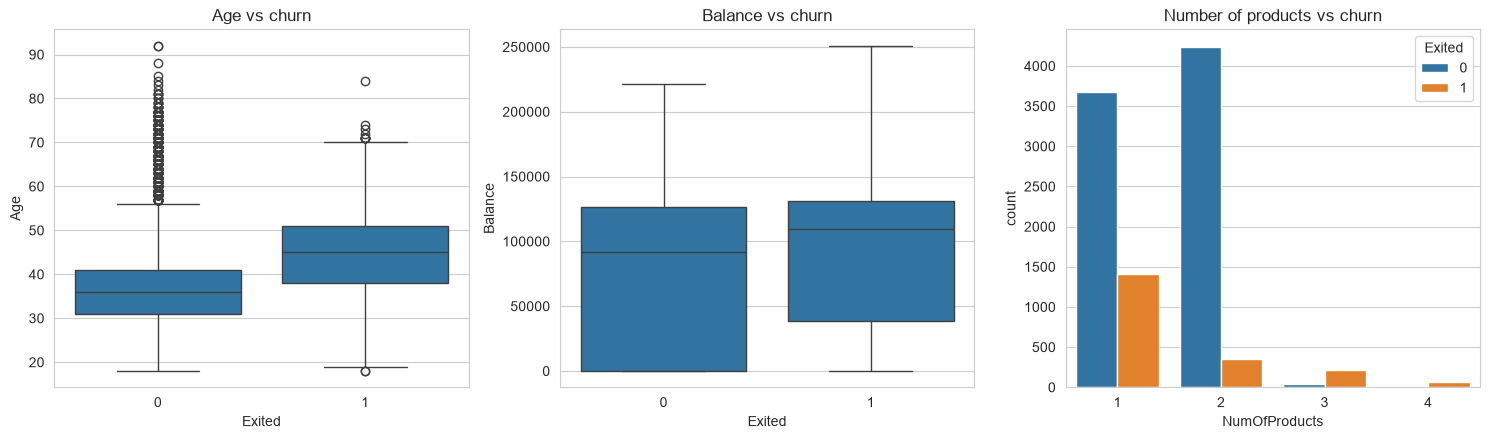

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.boxplot(data=df, x='Exited', y='Age', ax=axes[0])
axes[0].set_title('Age vs churn')

sns.boxplot(data=df, x='Exited', y='Balance', ax=axes[1])
axes[1].set_title('Balance vs churn')

sns.countplot(data=df, x='NumOfProducts', hue='Exited', ax=axes[2])
axes[2].set_title('Number of products vs churn')

plt.tight_layout()
plt.show()

Churned customers skew older. And here's the one that surprised me most - customers with 3 or 4 products churn way more than customers with 1 or 2. I would've guessed the opposite (more products = more locked in), but the data says otherwise. This ends up being one of the strongest predictors once we get to modeling.

## 5. Activity status and credit card ownership

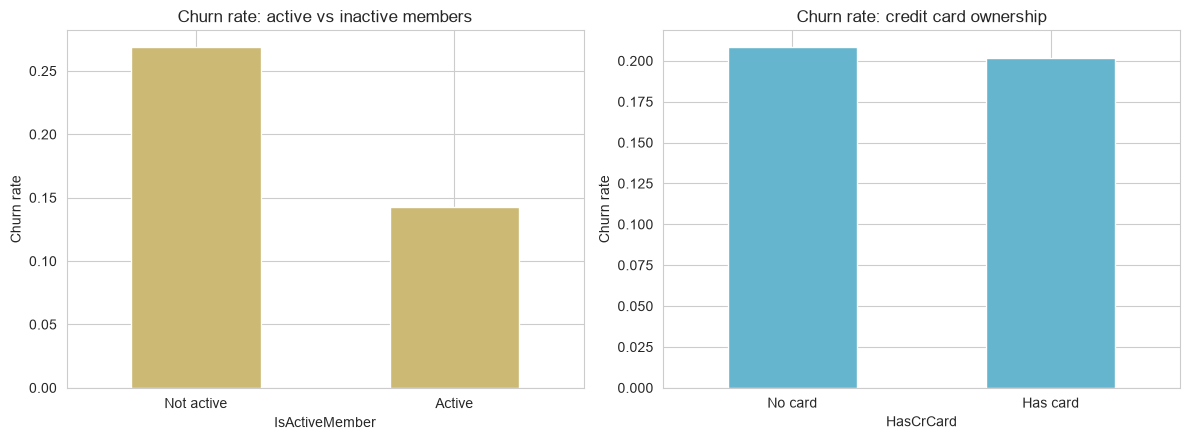

IsActiveMember
0    0.268509
1    0.142691
Name: Exited, dtype: float64

HasCrCard
0    0.208149
1    0.201843
Name: Exited, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

active_churn = df.groupby('IsActiveMember')['Exited'].mean()
active_churn.plot(kind='bar', ax=axes[0], color='#CCB974')
axes[0].set_xticklabels(['Not active', 'Active'], rotation=0)
axes[0].set_ylabel('Churn rate')
axes[0].set_title('Churn rate: active vs inactive members')

card_churn = df.groupby('HasCrCard')['Exited'].mean()
card_churn.plot(kind='bar', ax=axes[1], color='#64B5CD')
axes[1].set_xticklabels(['No card', 'Has card'], rotation=0)
axes[1].set_ylabel('Churn rate')
axes[1].set_title('Churn rate: credit card ownership')

plt.tight_layout()
plt.show()

print(active_churn)
print()
print(card_churn)

Inactive members churn at roughly double the rate of active ones. Out of everything in this dataset this is probably the most useful finding for an actual bank, since activity level is something they can try to influence (engagement campaigns etc) unlike age or geography. Credit card ownership barely matters on its own, which kind of surprised me too.

## 6. Correlation matrix (numeric features)

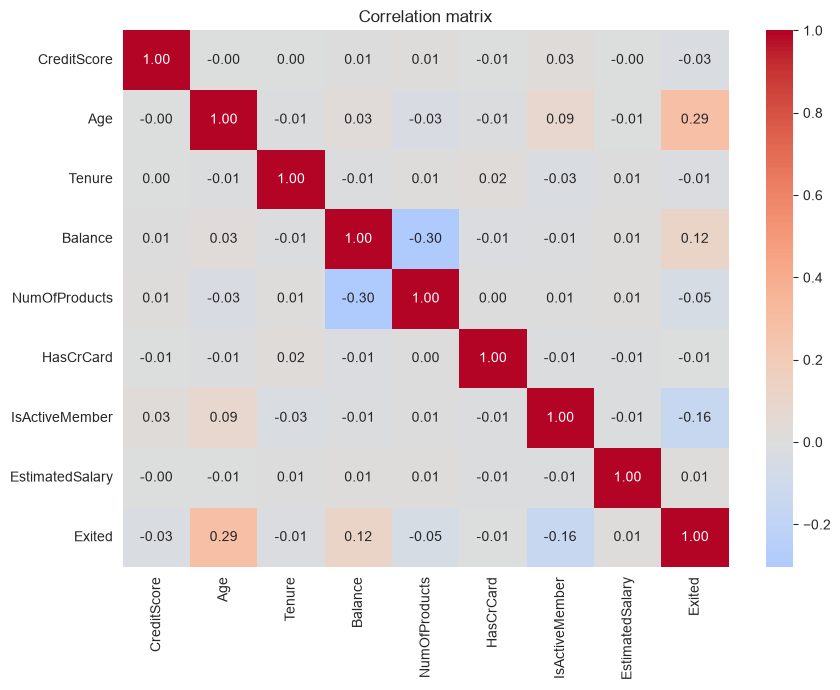

In [15]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
                'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

Nothing has a strong linear correlation with churn on its own - `Age` (+0.29) and `IsActiveMember` (-0.16) are the biggest, and even those are weak. Makes sense though, since the NumOfProducts effect we saw above isn't linear at all (it's the middle values that behave weirdly, not a steady trend), so a plain correlation matrix wouldn't catch it. This is basically the justification for using tree-based models instead of just logistic regression - see `src/train_model.py` and `src/explain.py`.

## 7. Engineered features - quick sanity check

In [16]:
eda_df = df.copy()
eda_df['BalanceSalaryRatio'] = eda_df['Balance'] / eda_df['EstimatedSalary'].replace(0, np.nan)
eda_df['BalanceSalaryRatio'] = eda_df['BalanceSalaryRatio'].fillna(0)
eda_df['ProductDensity'] = eda_df['NumOfProducts'] / (eda_df['Tenure'] + 1)
eda_df['EngagementProductScore'] = eda_df['IsActiveMember'] * eda_df['NumOfProducts']
eda_df['AgeTenureInteraction'] = eda_df['Age'] * eda_df['Tenure']

eda_df.groupby('Exited')[['BalanceSalaryRatio', 'ProductDensity',
                            'EngagementProductScore', 'AgeTenureInteraction']].mean()

,BalanceSalaryRatio,ProductDensity,EngagementProductScore,AgeTenureInteraction
Exited,,,,
0,2.478339,0.368263,0.851689,188.215622
1,9.352977,0.362913,0.553756,220.559156


`EngagementProductScore` (active x num products) splits the two groups better than either feature does alone, which is why I kept it as an engineered feature going into modeling.

## Takeaways before moving to modeling

- Churn rate is 20.4% overall
- Germany churns noticeably more than France/Spain
- 3-4 products = higher churn, which is backwards from what I expected
- Inactive members churn at ~2x the rate of active ones - probably the most useful lever for a retention team since it's something they can actually act on
- Churned customers skew older on average
- Nothing is a strong standalone linear predictor, which is why tree-based models make more sense here than logistic regression alone (though I still trained LR as a baseline)